In [108]:
import dask.dataframe as dd
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap
from sklearn.metrics import mean_squared_error, r2_score

In [109]:
filePaths = ["Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=0/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=1/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=2/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=3/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=4/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=5/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=6/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=7/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=8/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=9/part-0.parquet"
                  ]
olaolaola = dd.read_parquet(filePaths)

In [110]:
df, test_df = olaolaola.random_split([0.8, 0.2], random_state=42)

In [111]:
features = ['feature_00','feature_01','feature_02','feature_03','feature_04','feature_05','feature_06','feature_07','feature_08','feature_09','feature_10','feature_11','feature_12','feature_13','feature_14','feature_15','feature_16','feature_17','feature_18','feature_19','feature_20','feature_21','feature_22','feature_23','feature_24','feature_25','feature_26','feature_27','feature_28','feature_29','feature_30','feature_31','feature_32','feature_33','feature_34','feature_35','feature_36','feature_37','feature_38','feature_39','feature_40','feature_41','feature_42','feature_43','feature_44','feature_45','feature_46','feature_47','feature_48','feature_49','feature_50','feature_51','feature_52','feature_53','feature_54','feature_55','feature_56','feature_57','feature_58','feature_59','feature_60','feature_61','feature_62','feature_63','feature_64','feature_65','feature_66','feature_67','feature_68','feature_69','feature_70','feature_71','feature_72','feature_73','feature_74','feature_75','feature_76','feature_77','feature_78']
responders = ['responder_0','responder_1','responder_2','responder_3','responder_4','responder_5','responder_6','responder_7','responder_8']
target = ['responder_6']

In [112]:
nanColumns = {}
with open("Info/Missing Percentage.txt", "r") as f:
    for line in f:
        if float(line.split()[1]) > 0:
            nanColumns[line.split()[0]] = float(line.split()[1])

# Creating Missingness Flags
for column in nanColumns.keys():
    df[f"{column}_nan"] = df[column].isna().astype(int)


In [113]:
imputeColumns = []
nonImputeColumns = []
for column in nanColumns.keys():
    if nanColumns[column] > 10:
        nonImputeColumns.append(column)
    else:
        imputeColumns.append(column)
print(imputeColumns)
print(nonImputeColumns)

['feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_08', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_32', 'feature_33', 'feature_37', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_73', 'feature_74', 'feature_75', 'feature_76', 'feature_77', 'feature_78']
['feature_21', 'feature_26', 'feature_27', 'feature_31']


In [114]:
sampledf = df.sample(frac=0.001).compute()

In [115]:
sampledf = pd.DataFrame(StandardScaler().fit_transform(sampledf),index=sampledf.index,columns=sampledf.columns)

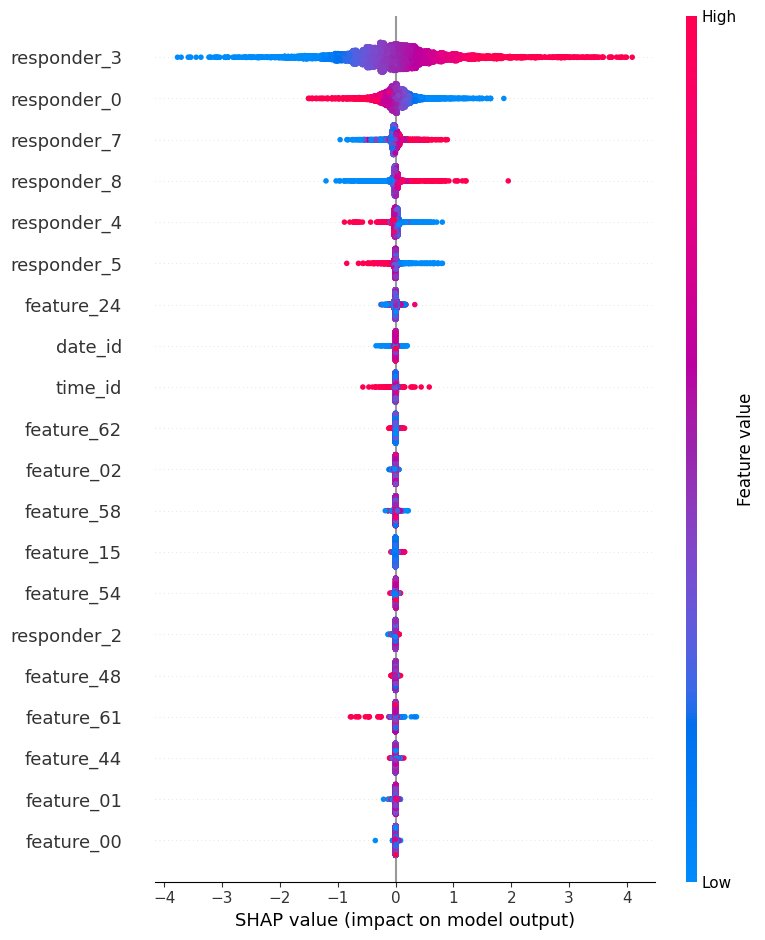

In [116]:
checkdf = sampledf.copy()

X = checkdf.drop('responder_6', axis=1)
y = checkdf['responder_6']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputeDF = X_test[imputeColumns]
imputedArray = IterativeImputer(random_state=42, max_iter=45).fit_transform(imputeDF)
X_test[imputeColumns] = imputedArray

model = xgb.XGBRegressor(random_state=42)  
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

del checkdf


In [117]:
imputeDF = sampledf[imputeColumns]
imputedArray = IterativeImputer(random_state=42, max_iter=45).fit_transform(imputeDF)
sampledf[imputeColumns] = imputedArray

In [118]:
for column in nonImputeColumns:
    print(f"{column}: {sampledf[column].corr(sampledf['responder_6'])}")

feature_21: 0.0050307419504559145
feature_26: 0.006452198791964101
feature_27: -0.0011776184622008469
feature_31: 0.0054923612692286475


In [119]:
sampledf = sampledf.drop(columns = nonImputeColumns)

In [120]:
corrMatrix = sampledf.corr()
corrMatrix.to_csv('./Info/CorrelationMatrix.csv')

In [121]:
target = sampledf['responder_6']  

X_train, X_test, y_train, y_test = train_test_split(sampledf, target.values , test_size=0.5, random_state=42)
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


MSE: 0.004734692933596204
R2: 0.9952314732899229
